## Esempio
Questo notebook contiene degli esempi di codice che vi potranno essere utili per svolgere l'esercitazione 1. Ovviamente non è proprpio ugual al testo dell'esercitazione ma vi consente di avere gli strumenti di base per iniziare modificando il codice opportunamente.

Più precisamente il codice contenuto in questo notebook mostra come estraendo numeri random distribuiti secondo una gaussiana si possa generare un istogramma e accedere al contenuto dei bin dell'istogramma

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import math

La larghezza dei bin è 0.10000000000000009
I bordi dei bin sono [-4.  -3.9 -3.8 -3.7 -3.6 -3.5 -3.4 -3.3 -3.2 -3.1 -3.  -2.9 -2.8 -2.7
 -2.6 -2.5 -2.4 -2.3 -2.2 -2.1 -2.  -1.9 -1.8 -1.7 -1.6 -1.5 -1.4 -1.3
 -1.2 -1.1 -1.  -0.9 -0.8 -0.7 -0.6 -0.5 -0.4 -0.3 -0.2 -0.1  0.   0.1
  0.2  0.3  0.4  0.5  0.6  0.7  0.8  0.9  1.   1.1  1.2  1.3  1.4  1.5
  1.6  1.7  1.8  1.9  2.   2.1  2.2  2.3  2.4  2.5  2.6  2.7  2.8  2.9
  3.   3.1  3.2  3.3  3.4  3.5  3.6  3.7  3.8  3.9  4. ]
I centri dei bin sono [-3.95 -3.85 -3.75 -3.65 -3.55 -3.45 -3.35 -3.25 -3.15 -3.05 -2.95 -2.85
 -2.75 -2.65 -2.55 -2.45 -2.35 -2.25 -2.15 -2.05 -1.95 -1.85 -1.75 -1.65
 -1.55 -1.45 -1.35 -1.25 -1.15 -1.05 -0.95 -0.85 -0.75 -0.65 -0.55 -0.45
 -0.35 -0.25 -0.15 -0.05  0.05  0.15  0.25  0.35  0.45  0.55  0.65  0.75
  0.85  0.95  1.05  1.15  1.25  1.35  1.45  1.55  1.65  1.75  1.85  1.95
  2.05  2.15  2.25  2.35  2.45  2.55  2.65  2.75  2.85  2.95  3.05  3.15
  3.25  3.35  3.45  3.55  3.65  3.75  3.85  3.95]
Il vettore dei

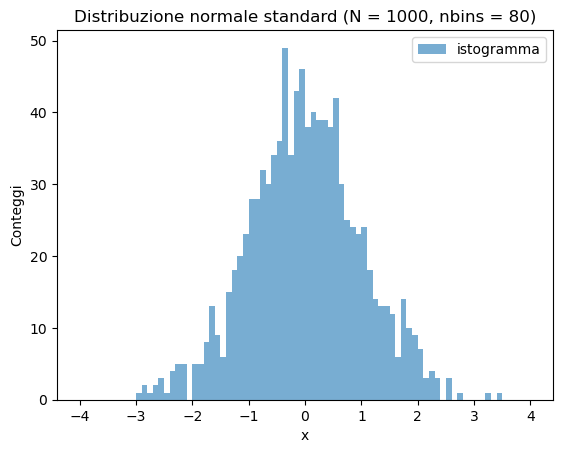

In [ ]:
#estraggo numeri casuali con densità di probabilità gaussiana
N = 1000
data = np.random.normal(0, 1, N) #Nota: guardate la slide 50 delle slides "2 - Slides python" per la generazione uniforme

#creo un istogramma e tengo nota del contenuto dei bin e della loro larghezza
#vedi documentazione https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.hist.html
#decido di usare 80 bin tra -4 e 4
nbins = 80
#il parametro alpha nel comando successivo serve solo per definire la trasparenza del plot
h, bordi, patches = plt.hist(data, bins=nbins, range=(-4,4), alpha=0.6, label='istogramma') 

#calcolo la larghezza di un bin
delta_x = bordi[1] - bordi[0]

print(f"La larghezza dei bin è {delta_x}")
#calcolo le coordinate dei centri dei bin
centri = (bordi[:-1] + bordi[1:]) / 2
print(f"I bordi dei bin sono {bordi}")
print(f"I centri dei bin sono {centri}")
print(f"Il vettore dei bordi ha {len(bordi)} elementi")
print(f"Il vettore dei centri ha {len(centri)} elementi")

plt.xlabel("x")
plt.ylabel("Conteggi")
plt.title(f"Distribuzione print(f"Il vettore dei centri ha {len(centri)} elementi")
normale standard (N = {N}, nbins = {nbins})")
plt.legend()
plt.show()

In [3]:
#se non mi interessa la parte grafica posso generare l'istogramma anche in un altro modo equivalente senza graficarlo

h_1, bordi_1 = np.histogram(data, bins=nbins, range=(-4,4))

#posso verificare che il risultato è uguale a prima
print(f"È vero che h e h_1 sono uguali? {np.array_equal(h, h_1)}?")
print(f"È vero che bordi e bordi_1 sono uguali? {np.array_equal(bordi, bordi_1)}")


#posso prendere il contenuto di un certo bin, per esempio il numero 40
print(f"Quanto è alto il contenuto del bin numero 40 centrato in {centri[40]:.2f}? {h[40]}")


È vero che h e h_1 sono uguali? True?
È vero che bordi e bordi_1 sono uguali? True
Quanto è alto il contenuto del bin numero 40 centrato in 0.05? 38.0


#### Supponiamo ora di voler graficare la densità di probabilità sopra l'istrogramma. Dopo che uso plt.show() qualunque grafico avessi creato non esiste più quindi la parte grafica si deve rifare.

In [4]:
#definisco prima di iniziare la mia funzione
# Parametri della gaussiana
mu = 0
sigma = 1

# Funzione densità di probabilità (PDF) della gaussiana con normale come default
def gaussian_pdf(x, mu=0, sigma=1):
    return (1 / (sigma * math.sqrt(2 * math.pi))) * np.exp(-((x - mu) ** 2) / (2 * sigma ** 2))

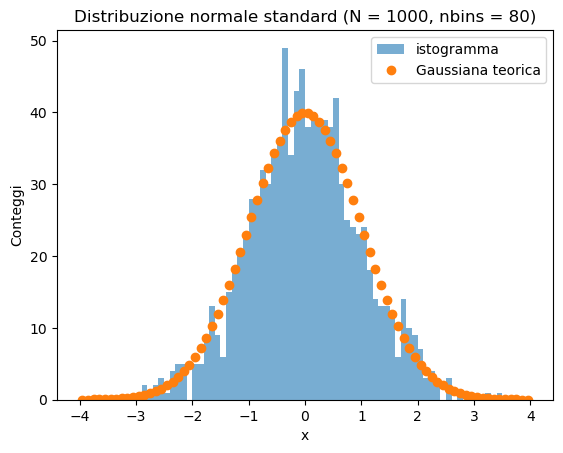

In [5]:
#ricopio la prima parte del codice e aggiungo il plot della gaussiana
nbins = 80
h, bordi, patches = plt.hist(data, bins=nbins, range=(-4,4), alpha=0.6, label='istogramma')

#calcolo la larghezza di un bin
delta_x = bordi[1] - bordi[0]

#calcolo le coordinate dei centri dei bin
centri = (bordi[:-1] + bordi[1:]) / 2

#il comando successivo serve ad aggiungere i pallini arancioni all'istogramma
#il parametro 'o' serve ad avere i pallini invece che una linea che unisce i punti
plt.plot(centri, gaussian_pdf(centri)*delta_x*N, 'o', label="Gaussiana teorica")

plt.xlabel("x")
plt.ylabel("Conteggi")
plt.title(f"Distribuzione normale standard (N = {N}, nbins = {nbins})")
plt.legend()
plt.show()

In [6]:
#caso in cui bisogna costruire un vettore di punti tutti uguali

contenuto = 42 #numero che deve diventare un vettore
lunghezza = 5 #lunghezza del vettore

lista_punti = [] #creo una lista vuota

for i in range(lunghezza):
    lista_punti.append(contenuto)

print(f"Il contenuto della lista è {lista_punti}")

#Alternativa con array numpy, see https://numpy.org/doc/stable/reference/generated/numpy.full.html
array_punti = np.full(lunghezza, contenuto)
print(f"Il contenuto dell'array è {array_punti}")

Il contenuto della lista è [42, 42, 42, 42, 42]
Il contenuto dell'array è [42 42 42 42 42]
